
image 1/1 /Users/vi/TTCS/source/SourceCodePlate/training/../samples/img_plate_6.png: 960x896 3 plates, 288.8ms
Speed: 5.5ms preprocess, 288.8ms inference, 2.2ms postprocess per image at shape (1, 3, 960, 896)


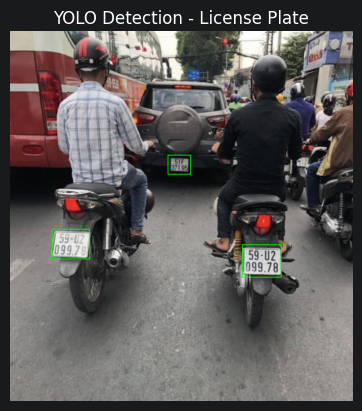

In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("../model/best_plate_detection.pt")
img_path = "../samples/img_plate_6.png"
img = cv2.imread(img_path)

results = model(img_path)

for result in results:
    boxes = result.boxes.xyxy

    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.title("YOLO Detection - License Plate")
plt.show()

Sử dụng PaddleOCR để đọc kí tự từ khung crop từ YOLO.

In [12]:
from ultralytics import YOLO
import cv2
from paddleocr import PaddleOCR
import matplotlib.pyplot as plt

model = YOLO("../model/best_plate_detection.pt")
ocr = PaddleOCR(use_angle_cls = False,lang = 'en')
predict = model("../samples/img_plate_9.png")
img = cv2.imread("../samples/img_plate_9.png")
for r in predict:

    boxes = r.boxes.xyxy

    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        offset_w = int((x2 - x1) * 0.1)
        offset_h = int((y2 - y1) * 0.2)
        x1_crop = max(0, x1 - offset_w)
        y1_crop = max(0, y1 - offset_h)
        x2_crop = min(img.shape[1], x2 + 2*offset_w)
        y2_crop = min(img.shape[0], y2 + 2*offset_h)

        crop = img[y1_crop:y2_crop, x1_crop:x2_crop]

        ocr_result = ocr.ocr(crop)
        if ocr_result:
            res = ocr_result[0]

            texts = res['rec_texts']
            scores = res['rec_scores']

            for text, score in zip(texts, scores):
                print(f"Text: {text} | Confidence: {score:.2f}")

/var/folders/5l/xvvkbgln1qz502f2b5fvbfj40000gn/T/ipykernel_1750/177168145.py:7: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls = False,lang = 'en')
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/UVDoc`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redo


image 1/1 /Users/vi/TTCS/source/SourceCodePlate/training/../samples/img_plate_9.png: 576x960 3 plates, 220.7ms
Speed: 4.2ms preprocess, 220.7ms inference, 0.8ms postprocess per image at shape (1, 3, 576, 960)


/var/folders/5l/xvvkbgln1qz502f2b5fvbfj40000gn/T/ipykernel_1750/177168145.py:28: DeprecationWarning: Please use `predict` instead.
  ocr_result = ocr.ocr(crop)


Text: 38-AS | Confidence: 0.88
Text: 009.33 | Confidence: 1.00
Text: 29-G1 | Confidence: 0.98
Text: 764.49 | Confidence: 1.00
Text: 174.86 | Confidence: 0.99
Text: 98-61 | Confidence: 0.96


Test quay biển số bị nghiêng và kết quả dự đoán


/var/folders/5l/xvvkbgln1qz502f2b5fvbfj40000gn/T/ipykernel_1750/2290246851.py:72: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls = False,lang = 'en')
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/UVDoc`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To re

Text: 98-61 | Confidence: 0.96
Text: 174.86 | Confidence: 1.00


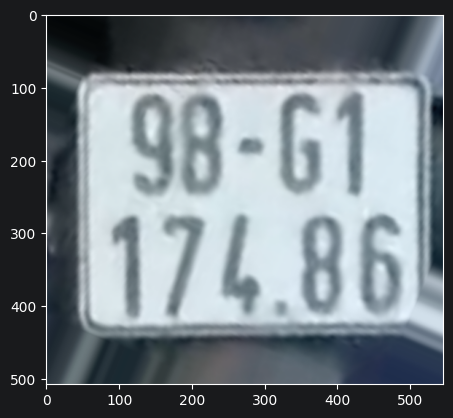

In [20]:
import cv2
import numpy as np
from paddleocr import PaddleOCR
import cv2
import numpy as np

import cv2
import numpy as np

def deskew_plate(plate):

    gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (3,3), 0)

    edges = cv2.Canny(blur, 50, 150)

    lines = cv2.HoughLinesP(
        edges,
        1,
        np.pi / 180,
        threshold=50,
        minLineLength=50,
        maxLineGap=10
    )

    if lines is None:
        return plate

    angles = []

    for line in lines:

        x1, y1, x2, y2 = line[0]

        angle = np.degrees(
            np.arctan2(y2 - y1, x2 - x1)
        )

        # chỉ lấy line gần ngang
        if -30 < angle < 30:
            angles.append(angle)

    if len(angles) == 0:
        return plate

    median_angle = np.median(angles)

    # nếu góc quá nhỏ thì bỏ
    if abs(median_angle) < 2:
        return plate

    (h, w) = plate.shape[:2]

    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(
        center,
        median_angle,
        1.0
    )

    rotated = cv2.warpAffine(
        plate,
        M,
        (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    return rotated
ocr = PaddleOCR(use_angle_cls = False,lang = 'en')
plate = cv2.imread("../results/crop_0_2.png")
plate = cv2.resize(plate, None, fx=2, fy=2)

if plate.shape[0] != 0 and plate.shape[1] != 0:
    plate = deskew_plate(plate)
plt.imshow(plate)
ocr_result = ocr.predict(plate)
if ocr_result:
    res = ocr_result[0]

    texts = res['rec_texts']
    scores = res['rec_scores']

    for text, score in zip(texts, scores):
        print(f"Text: {text} | Confidence: {score:.2f}")

Gamma

In [25]:
import cv2
import numpy as np

def enhance_plate(img):

    # =========================
    # 1. Resize ảnh
    # =========================
    upscaled = cv2.resize(
        img,
        None,
        fx=4,
        fy=4,
        interpolation=cv2.INTER_CUBIC
    )

    # =========================
    # 2. Chuyển grayscale
    # =========================
    gray = cv2.cvtColor(upscaled, cv2.COLOR_BGR2GRAY)

    # =========================
    # 3. CLAHE tăng tương phản
    # =========================
    clahe = cv2.createCLAHE(
        clipLimit=3.0,
        tileGridSize=(8, 8)
    )

    clahe_img = clahe.apply(gray)

    # =========================
    # 4. Gamma correction
    # =========================
    gamma = 1.8

    invGamma = 1.0 / gamma

    table = np.array([
        ((i / 255.0) ** invGamma) * 255
        for i in np.arange(256)
    ]).astype("uint8")

    gamma_img = cv2.LUT(clahe_img, table)

    # =========================
    # 5. Sharpen
    # =========================
    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])

    sharp = cv2.filter2D(gamma_img, -1, kernel)

    # =========================
    # 6. Adaptive Threshold
    # =========================
    thresh = cv2.adaptiveThreshold(
        sharp,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        11
    )

    return sharp, thresh


In [20]:
import numpy as np
import cv2

def adjust_gamma(image, gamma=1.2):

    invGamma = 1.0 / gamma

    table = np.array([
        ((i / 255.0) ** invGamma) * 255
        for i in np.arange(256)
    ]).astype("uint8")

    return cv2.LUT(image, table)

CLAHE

/var/folders/5l/xvvkbgln1qz502f2b5fvbfj40000gn/T/ipykernel_8265/3860737260.py:5: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls = False, lang = 'en')
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/UVDoc`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To re

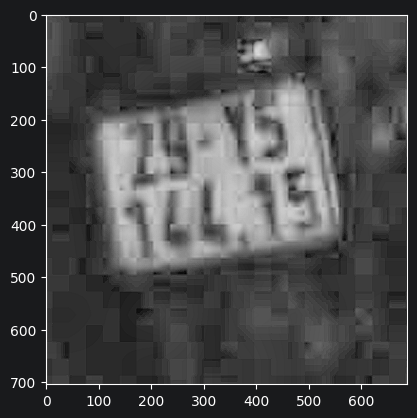

In [28]:
import matplotlib.pyplot as plt
import cv2
from paddleocr import PaddleOCR

ocr = PaddleOCR(use_angle_cls = False, lang = 'en')
frame = cv2.imread("crop_0_0.png")
# frame = adjust_gamma(frame)
# lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
#
# l, a, b = cv2.split(lab)
#
# clahe = cv2.createCLAHE(
#     clipLimit=2.0,
#     tileGridSize=(8,8)
# )
#
# l = clahe.apply(l)
#
# lab = cv2.merge((l,a,b))
#
# result = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
#
# result = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)
# blur = cv2.GaussianBlur(result, (3,3), 0)
# _,thresh = cv2.threshold(
#     blur,
#     0,
#     255,
#     cv2.THRESH_BINARY + cv2.THRESH_OTSU
# )
# result = cv2.cvtColor(thresh, cv2.COLOR_RGB2BGR)
result, threshold = enhance_plate(frame)
result = cv2.cvtColor(result, cv2.COLOR_GRAY2BGR)
plt.imshow(result)

ocr_result = ocr.predict(result)
if ocr_result:
    res = ocr_result[0]

    texts = res['rec_texts']
    scores = res['rec_scores']

    for text, score in zip(texts, scores):
        print(f"Text: {text} | Confidence: {score:.2f}")

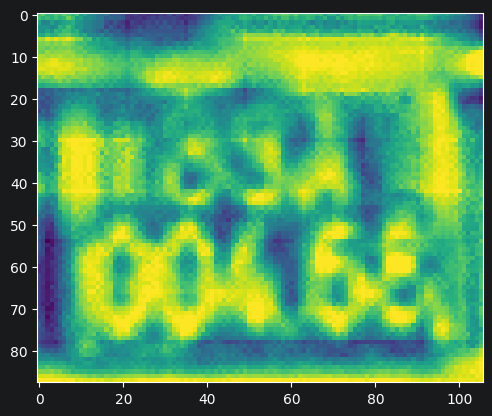

In [33]:
import cv2
import numpy as np
img = cv2.imread("../../OpenCVTest/crop_0_0.jpg")
img = cv2.resize(img, None, fx=2, fy=2)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(clipLimit)


/var/folders/5l/xvvkbgln1qz502f2b5fvbfj40000gn/T/ipykernel_1434/2727274404.py:7: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang='en')
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files.


image 1/1 /Users/vi/TTCS/source/SourceCodePlate/training/../samples/img_plate_1.png: 608x960 2 plates, 186.3ms
Speed: 2.7ms preprocess, 186.3ms inference, 0.8ms postprocess per image at shape (1, 3, 608, 960)
(596, 946, 3)


/var/folders/5l/xvvkbgln1qz502f2b5fvbfj40000gn/T/ipykernel_1434/2727274404.py:33: DeprecationWarning: Please use `predict` instead.
  result = ocr.ocr(top)


[{'input_path': None, 'page_index': None, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'input_img': array([[[59, ..., 42],
        ...,
        [70, ..., 53]],

       ...,

       [[58, ..., 46],
        ...,
        [67, ..., 50]]], shape=(66, 142, 3), dtype=uint8), 'model_settings': {'use_doc_orientation_classify': True, 'use_doc_unwarping': True}, 'angle': 180, 'rot_img': array([[[ 0, ...,  0],
        ...,
        [ 0, ...,  0]],

       ...,

       [[ 0, ...,  0],
        ...,
        [59, ..., 42]]], shape=(66, 142, 3), dtype=uint8), 'output_img': array([[[65, ..., 48],
        ...,
        [57, ..., 44]],

       ...,

       [[87, ..., 72],
        ...,
        [64, ..., 47]]], shape=(66, 142, 3), dtype=uint8)}, 'dt_polys': [], 'model_settings': {'use_doc_preprocessor': True, 'use_textline_orientation': True}, 'text_det_params': {'limit_side_len': 64, 'limit_type': 'min', 'thresh': 0.3, 'max_side_limit': 4000, 'box_thresh': 0.6, 'unclip_ratio': 1.5}, 'text

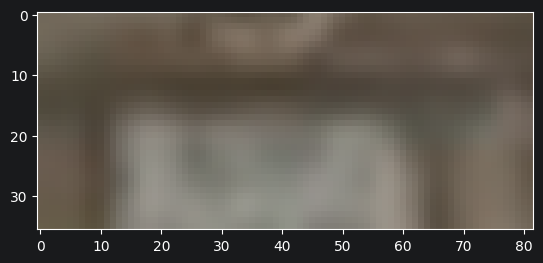

In [4]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR
import cv2

model = YOLO("../model/best_plate_detection.pt")
ocr = PaddleOCR(use_angle_cls=True, lang='en')
predict = model("../samples/img_plate_1.png")
img = cv2.imread("../samples/img_plate_1.png")
print(img.shape)

for r in predict:

    boxes = r.boxes.xyxy

    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        offset_w = int((x2 - x1) * 0.1)
        offset_h = int((y2 - y1) * 0.2)
        x1_crop = max(0, x1 - offset_w)
        y1_crop = max(0, y1 - offset_h)
        x2_crop = min(img.shape[1], x2 + 2*offset_w)
        y2_crop = min(img.shape[0], y2 + 2*offset_h)

        crop = img[y1_crop:y2_crop, x1_crop:x2_crop]
        crop = cv2.resize(crop, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        # cv2.imwrite("crop.png", crop)
        h, w = crop.shape[:2]
        top = crop[:h//2, :]
        bottom = crop[h//2:, :]
        plt.imshow(top)
        result = ocr.ocr(top)
        plate = ""
        if result:
            texts = result[0]['rec_texts']
            scores = result[0]['rec_scores']
            plate = " ".join(texts)
        if len(scores) > 0:
            conf = sum(scores)/len(scores)

        if conf > 0:
            cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.putText(img, plate, (x1, y1-10), cv2.FONT_HERSHEY_COMPLEX, 0.7, (0,255,0), 2)
        print(result)
        # plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

/var/folders/5l/xvvkbgln1qz502f2b5fvbfj40000gn/T/ipykernel_1434/1523044911.py:7: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang='en')
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files.

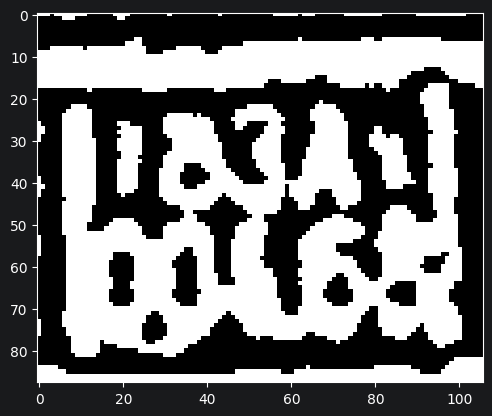

In [16]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR
import cv2
import numpy as np

ocr = PaddleOCR(use_angle_cls=True, lang='en')
# predict = model("../training/crop_0_0.png")
img = cv2.imread("../../OpenCVTest/crop_0_0.jpg")
img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# tăng tương phản
gray = cv2.equalizeHist(gray)

# làm nét
thresh = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11, 2
)
kernel = np.ones((2,2), np.uint8)
thin = cv2.erode(thresh, kernel, iterations=1)

thresh = cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR)

plt.imshow(thresh)
# h, w = thresh.shape
#
# top = thresh[:h//2, :]
# bottom = thresh[h//2:, :]
#
# # 👉 FIX QUAN TRỌNG
# top = cv2.cvtColor(top, cv2.COLOR_GRAY2BGR)
# bottom = cv2.cvtColor(bottom, cv2.COLOR_GRAY2BGR)
#
# # 👉 resize thêm
# top = cv2.resize(top, None, fx=2, fy=2)
# bottom = cv2.resize(bottom, None, fx=2, fy=2)
#
# plt.imshow(bottom)
# print("Top:", ocr.ocr(top))
# print("Bottom:", ocr.ocr(bottom))
# offset_w = int((x2 - x1) * 0.1)
# offset_h = int((y2 - y1) * 0.2)
# x1_crop = max(0, x1 - offset_w)
# y1_crop = max(0, y1 - offset_h)
# x2_crop = min(img.shape[1], x2 + 2*offset_w)
# y2_crop = min(img.shape[0], y2 + 2*offset_h)
#
# crop = img[y1_crop:y2_crop, x1_crop:x2_crop]
# crop = cv2.resize(crop, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
# # cv2.imwrite("crop.png", crop)
# h, w = crop.shape[:2]
# top = crop[:h//2, :]
# bottom = crop[h//2:, :]
# plt.imshow(top)
# result = ocr.ocr(top)
# print(result)

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.pad

[{'input_path': None, 'page_index': None, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'input_img': array([[[ 69, ...,  69],
        ...,
        [ 72, ...,  72]],

       ...,

       [[120, ..., 120],
        ...,
        [114, ..., 114]]], shape=(88, 106, 3), dtype=uint8), 'model_settings': {'use_doc_orientation_classify': True, 'use_doc_unwarping': True}, 'angle': 180, 'rot_img': array([[[ 0, ...,  0],
        ...,
        [ 0, ...,  0]],

       ...,

       [[ 0, ...,  0],
        ...,
        [68, ..., 68]]], shape=(88, 106, 3), dtype=uint8), 'output_img': array([[[113, ..., 113],
        ...,
        [ 93, ...,  93]],

       ...,

       [[ 91, ...,  91],
        ...,
        [100, ..., 100]]], shape=(88, 106, 3), dtype=uint8)}, 'dt_polys': [], 'model_settings': {'use_doc_preprocessor': True, 'use_textline_orientation': True}, 'text_det_params': {'limit_side_len': 64, 'limit_type': 'min', 'thresh': 0.3, 'max_side_limit': 4000, 'box_thresh': 0.6, 'unclip_rat

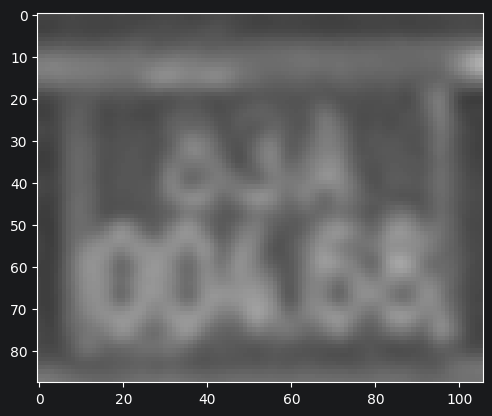

In [19]:
from realesrgan import RealESRGAN
from PIL import Image
import cv2

model = RealESRGAN('cpu', scale=4)
model.load_weights('RealESRGAN_x4.pth')

img = Image.open("../../OpenCVTest/crop_0_0.jpg")
sr_img = model.predict(img)

sr_img = cv2.cvtColor(np.array(sr_img), cv2.COLOR_RGB2BGR)
plt.imshow(sr_img)
result = ocr.ocr(sr_img)